>### **Fase 1: Limpieza y Preprocesamiento de Datos**

##### **Objetivo: Cargar los datos, identificar valores faltantes, duplicados y realizar un preprocesamiento inicial para preparar el análisis.**

**Cargar los tres datasets:**

Historicos_Ordenes.csv, Registros_Condiciones.csv, Caracteristicas_Equipos.csv

**Exploración básica:**

Visualización de las primeras filas.

Revisión de las dimensiones de los datasets.

Verificación de tipos de datos y valores nulos.

Estadísticas descriptivas iniciales.




In [1]:
# Obtener la Ruta absoluta de la carpeta que contiene los archivos, y copiarla para cargar los datasets.
import os
print(os.getcwd())

import pandas as pd

# Rutas de los archivos en el entorno local (adaptar en Azure cuando sea necesario)
path_caracteristicas = '/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Caracteristicas_Equipos.csv'
path_historicos = '/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Historicos_Ordenes.csv'
path_condiciones = '/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Registros_Condiciones.csv'

# Carga de los datasets
caracteristicas_equipos = pd.read_csv(path_caracteristicas)
historicos_ordenes = pd.read_csv(path_historicos)
registros_condiciones = pd.read_csv(path_condiciones)

# Visualización básica: primeras filas, dimensiones y tipos de datos
exploracion_inicial = {
    "Caracteristicas_Equipos": {
        "shape": caracteristicas_equipos.shape,
        "info": caracteristicas_equipos.info(),
        "head": caracteristicas_equipos.head(),
        "nulls": caracteristicas_equipos.isnull().sum()
    },
    "Historicos_Ordenes": {
        "shape": historicos_ordenes.shape,
        "info": historicos_ordenes.info(),
        "head": historicos_ordenes.head(),
        "nulls": historicos_ordenes.isnull().sum()
    },
    "Registros_Condiciones": {
        "shape": registros_condiciones.shape,
        "info": registros_condiciones.info(),
        "head": registros_condiciones.head(),
        "nulls": registros_condiciones.isnull().sum()
    }
}

exploracion_inicial




/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    505 non-null    int64 
 1   Tipo_Equipo                  505 non-null    object
 2   Fabricante                   505 non-null    object
 3   Modelo                       505 non-null    object
 4   Potencia_kW                  505 non-null    int64 
 5   Horas_Recomendadas_Revision  505 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Orden             10020 non-null  int64  
 1  

{'Caracteristicas_Equipos': {'shape': (505, 6),
  'info': None,
  'head':    ID_Equipo    Tipo_Equipo Fabricante Modelo  Potencia_kW  \
  0          1          Motor  Schneider   X100         1009   
  1          2          Motor        ABB   Z300         1220   
  2          3          Motor         GE   Y200         3733   
  3          4  Transformador    Siemens   X100          662   
  4          5      Compresor        ABB   Y200          982   
  
     Horas_Recomendadas_Revision  
  0                         9656  
  1                         2165  
  2                         6674  
  3                         1480  
  4                         4282  ,
  'nulls': ID_Equipo                      0
  Tipo_Equipo                    0
  Fabricante                     0
  Modelo                         0
  Potencia_kW                    0
  Horas_Recomendadas_Revision    0
  dtype: int64},
 'Historicos_Ordenes': {'shape': (10020, 7),
  'info': None,
  'head':    ID_Orden  ID_Equipo 

>### **Carga de Datos y Exploración Inicial (EDA Preliminar):**


INFORME EDA PRELIMINAR: Características de Equipos

Dimensiones del dataset: (505, 6)

Tipos de datos:
ID_Equipo                       int64
Tipo_Equipo                    object
Fabricante                     object
Modelo                         object
Potencia_kW                     int64
Horas_Recomendadas_Revision     int64
dtype: object

Valores nulos por columna:
ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
dtype: int64

Estadísticas Descriptivas:
         ID_Equipo Tipo_Equipo Fabricante Modelo  Potencia_kW  \
count   505.000000         505        505    505   505.000000   
unique         NaN           4          4      4          NaN   
top            NaN   Generador        ABB   Z300          NaN   
freq           NaN         135        133    142          NaN   
mean    248.049505         NaN        NaN    NaN  2410.994059 

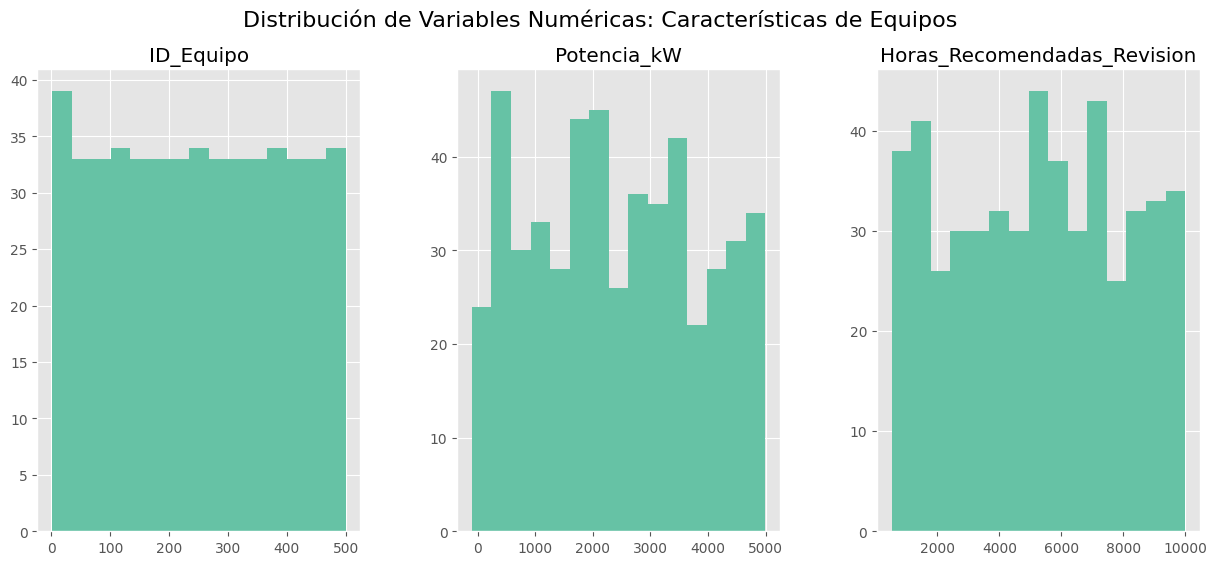

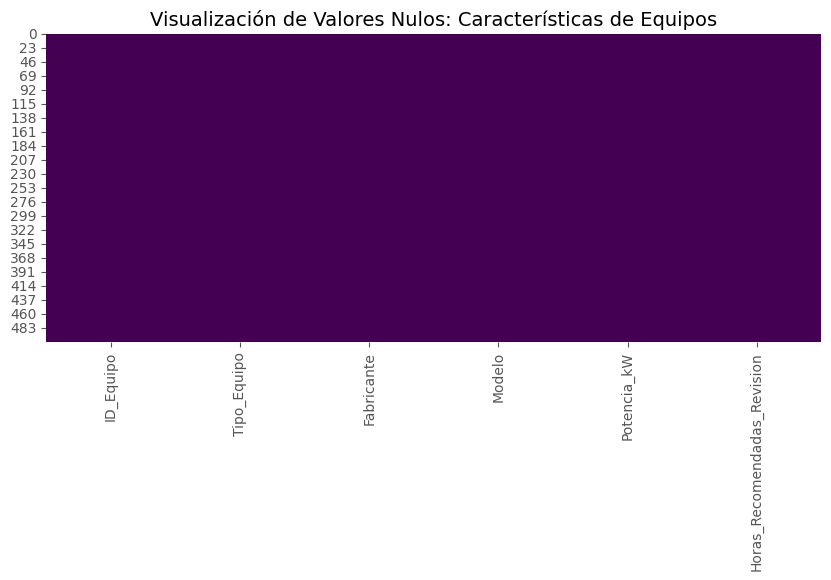


INFORME EDA PRELIMINAR: Históricos de Órdenes de Trabajo

Dimensiones del dataset: (10020, 7)

Tipos de datos:
ID_Orden                 int64
ID_Equipo                int64
Fecha                   object
Tipo_Mantenimiento      object
Costo_Mantenimiento    float64
Duracion_Horas           int64
Ubicacion               object
dtype: object

Valores nulos por columna:
ID_Orden                0
ID_Equipo               0
Fecha                   0
Tipo_Mantenimiento      0
Costo_Mantenimiento    50
Duracion_Horas          0
Ubicacion               0
dtype: int64

Estadísticas Descriptivas:
           ID_Orden     ID_Equipo                Fecha Tipo_Mantenimiento  \
count   10020.00000  10020.000000                10020              10020   
unique          NaN           NaN                10000                  2   
top             NaN           NaN  2020-01-01 00:00:00         Correctivo   
freq            NaN           NaN                    2               5098   
mean     4990.53992  

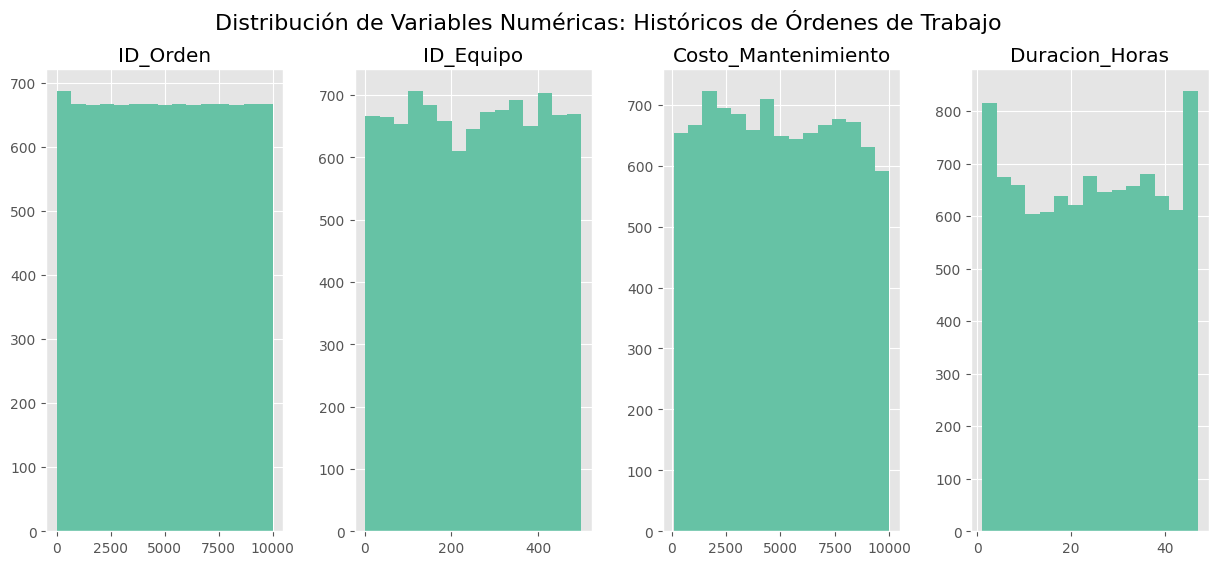

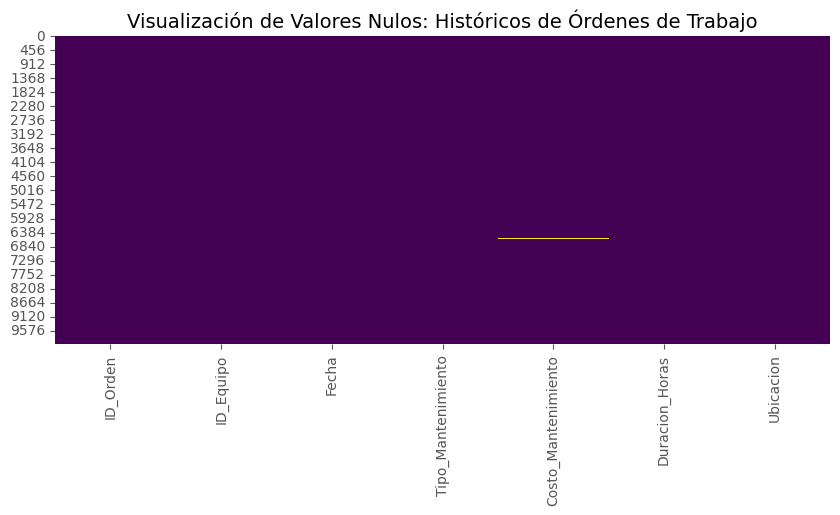


INFORME EDA PRELIMINAR: Registros de Condiciones Operativas

Dimensiones del dataset: (9000, 6)

Tipos de datos:
ID_Registro           int64
ID_Equipo             int64
Fecha                object
Temperatura_C       float64
Vibracion_mm_s      float64
Horas_Operativas    float64
dtype: object

Valores nulos por columna:
ID_Registro          0
ID_Equipo            0
Fecha                0
Temperatura_C        0
Vibracion_mm_s       0
Horas_Operativas    40
dtype: int64

Estadísticas Descriptivas:
        ID_Registro    ID_Equipo                Fecha  Temperatura_C  \
count   9000.000000  9000.000000                 9000    9000.000000   
unique          NaN          NaN                 9000            NaN   
top             NaN          NaN  2020-01-01 00:00:00            NaN   
freq            NaN          NaN                    1            NaN   
mean    4500.500000   245.532556                  NaN     102.710089   
std     2598.220545   144.190652                  NaN      59.324

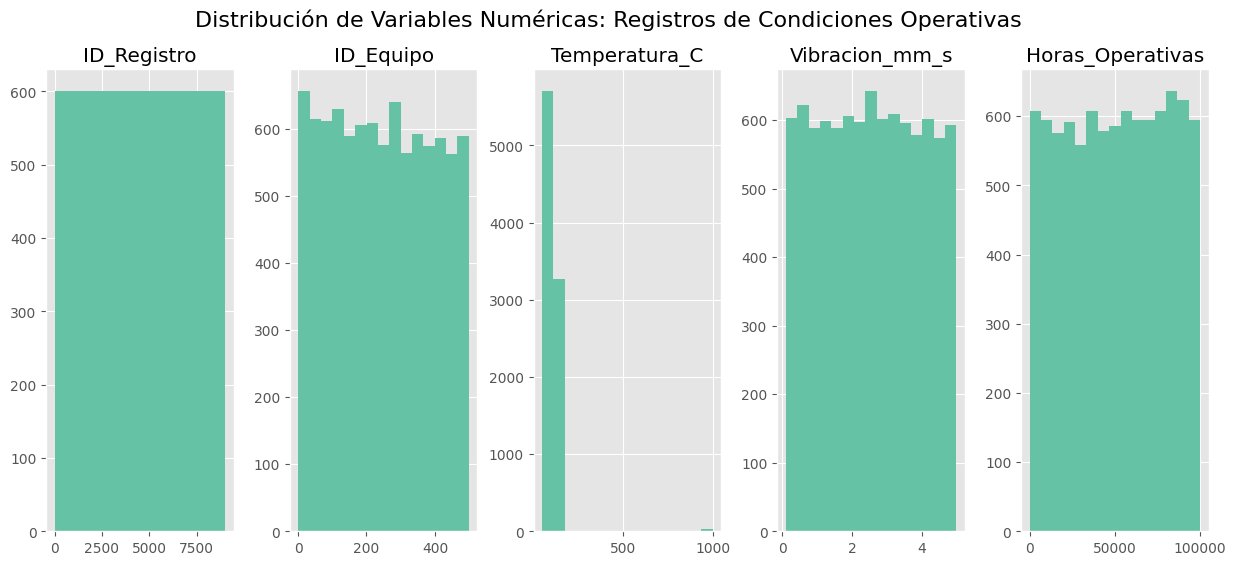

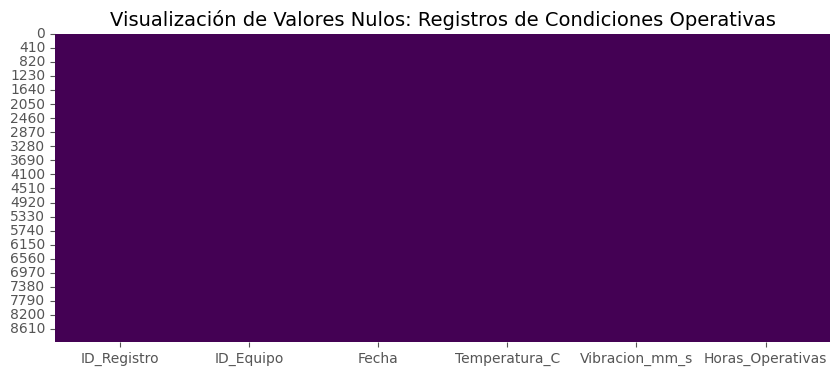

In [2]:
#!pip install seaborn """Instala la biblioteca quitando la celdilla, luego vuelvesela a poner"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las visualizaciones
plt.style.use('ggplot')
sns.set_palette('Set2')

# Carga de los datasets
caracteristicas_equipos = pd.read_csv(r'/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Caracteristicas_Equipos.csv')
historicos_ordenes = pd.read_csv(r'/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Historicos_Ordenes.csv')
registros_condiciones = pd.read_csv(r'/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Registros_Condiciones.csv')

# Informe EDA Preliminar
def eda_preliminar(df, nombre_dataset):
    print(f"\n\033[1;34m{'='*40}\033[0m")
    print(f"\033[1;34mINFORME EDA PRELIMINAR: {nombre_dataset}\033[0m")
    print(f"\033[1;34m{'='*40}\033[0m")
    
    # Información general
    print(f"\n\033[1mDimensiones del dataset:\033[0m {df.shape}")
    print(f"\n\033[1mTipos de datos:\033[0m")
    print(df.dtypes)
    
    # Valores nulos
    print(f"\n\033[1mValores nulos por columna:\033[0m")
    print(df.isnull().sum())
    
    # Estadísticas descriptivas
    print(f"\n\033[1mEstadísticas Descriptivas:\033[0m")
    print(df.describe(include='all'))
    
    # Visualización de distribuciones para variables numéricas
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    if len(num_cols) > 0:
        df[num_cols].hist(bins=15, figsize=(15, 6), layout=(1, len(num_cols)))
        plt.suptitle(f'Distribución de Variables Numéricas: {nombre_dataset}', fontsize=16)
        plt.show()
    
    # Visualización de valores nulos
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title(f'Visualización de Valores Nulos: {nombre_dataset}', fontsize=14)
    plt.show()

# Ejecutar EDA para cada dataset
eda_preliminar(caracteristicas_equipos, 'Características de Equipos')
eda_preliminar(historicos_ordenes, 'Históricos de Órdenes de Trabajo')
eda_preliminar(registros_condiciones, 'Registros de Condiciones Operativas')
